## Análisis de Componentes Principales (PCA)
Este notebook estandariza los datos, calcula los componentes principales, visualiza los agrupamientos por clúster verdadero y muestra el peso de cada variable en los componentes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

In [2]:
import os
base_path = 'data' if os.path.exists('data') else 'clustering/data'
df_completo = pd.read_csv(os.path.join(base_path, 'datos_embarazo_completo.csv'))
df_meta = pd.read_csv(os.path.join(base_path, 'metadatos_ground_truth.csv'))
df = df_completo.merge(df_meta, on='paciente_id')

cols_numericas = ['edad_anios', 'imc_pregestacional', 'semanas_gestacion', 
                  'num_embarazos_previos', 'num_partos_previos', 'embarazo_multiple',
                  'diabetes_previa', 'hipertension_cronica', 'peso_kg', 'talla_cm',
                  'ganancia_peso_kg', 'presion_sistolica', 'presion_diastolica',
                  'frecuencia_cardiaca']
X = df[cols_numericas]
y = df['cluster_verdadero']

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)
componentes = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=componentes, columns=['PC1', 'PC2', 'PC3'])
df_pca['Cluster'] = 'C' + y.astype(str)

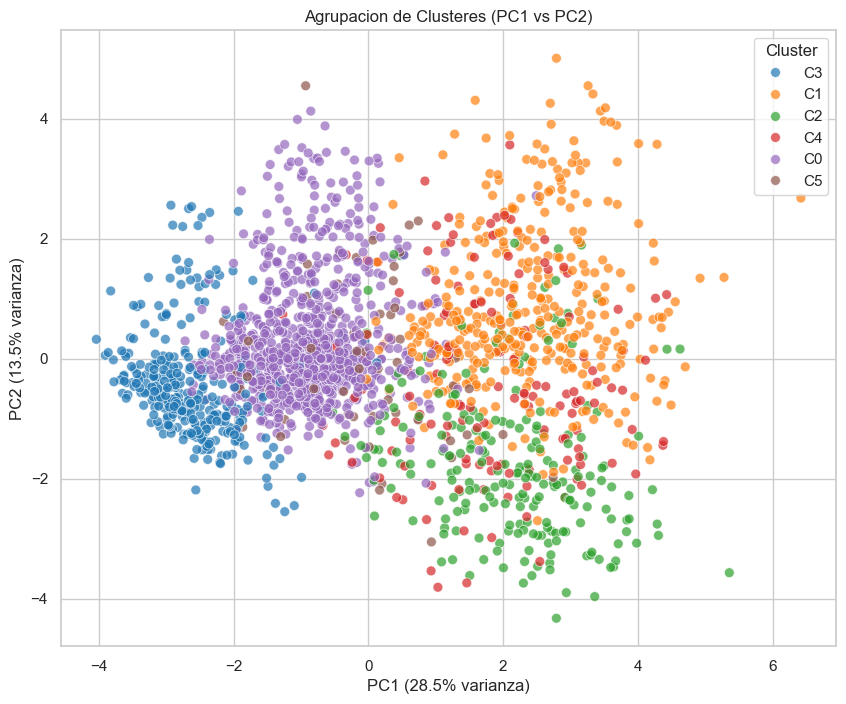

In [4]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, 
                palette='tab10', alpha=0.7, s=50)
plt.title('Agrupacion de Clusteres (PC1 vs PC2)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.legend(title='Cluster')
plt.show()

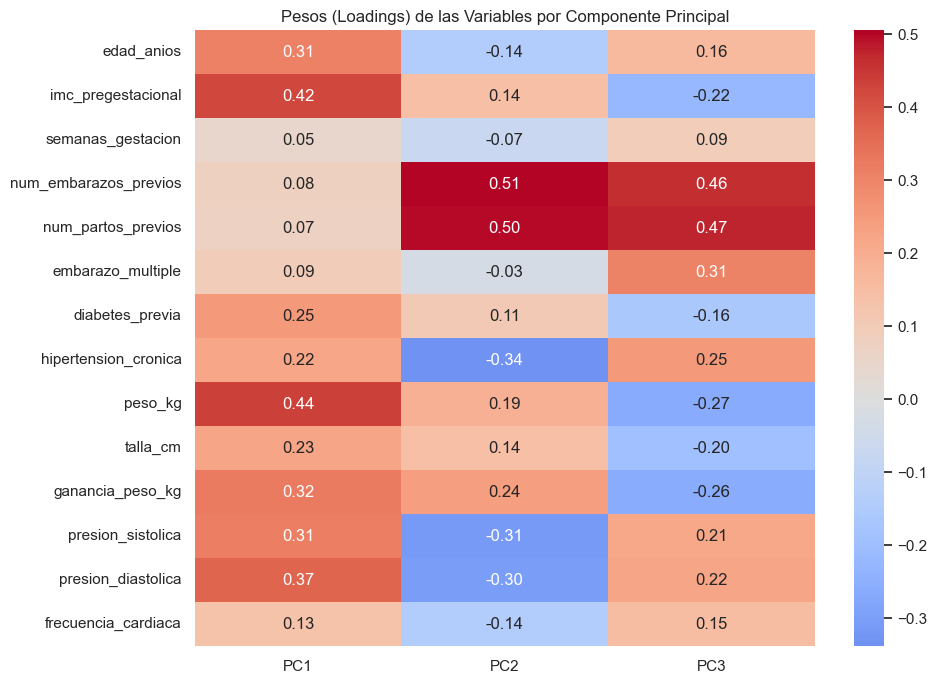

In [5]:
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2', 'PC3'], index=cols_numericas)
plt.figure(figsize=(10, 8))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Pesos (Loadings) de las Variables por Componente Principal')
plt.show()